In [ ]:
import cv2
import time
import torch
from ultralytics import YOLO
import os
import csv
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

: 

# Import csv file with frame,x,y,vel,datetime

In [ ]:
# input_video_path = "Video/New_8229-3-4-25_Sleep Deprivation_video.mp4"
# csv_path = "Trajectory & Speed Data  New 8229 - Rat 2 - 3-4-25 START_2025-03-04_Sleep Deprivation.csv"

input_video_path = "Video/Feedback Deprivation - Full File - Rat 2- 4-25-25 Start_video.mp4"
csv_path = "Feedback Trajectory and Speed Data - Full File - Rat 2- 4-25-25 Start_video.csv"

In [21]:
cap = cv2.VideoCapture(input_video_path)
if not cap.isOpened():
    # Try to get frame dimensions from a known source if video fails
    # For demonstration, let's assume some defaults if video can't be opened
    # but ideally, you'd have these stored or ensure the video path is always valid
    print(f"Warning: Could not open video {input_video_path}. Using default frame dimensions (1920x1080).")
    frame_w, frame_h = 1920, 1080 # Example default
else:
    frame_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release() # Release the capture object as we only needed dimensions

print(f"Using frame dimensions: Width={frame_w}, Height={frame_h}")

Using frame dimensions: Width=640, Height=480


# Complete Plot Trajectory

### Line Plot

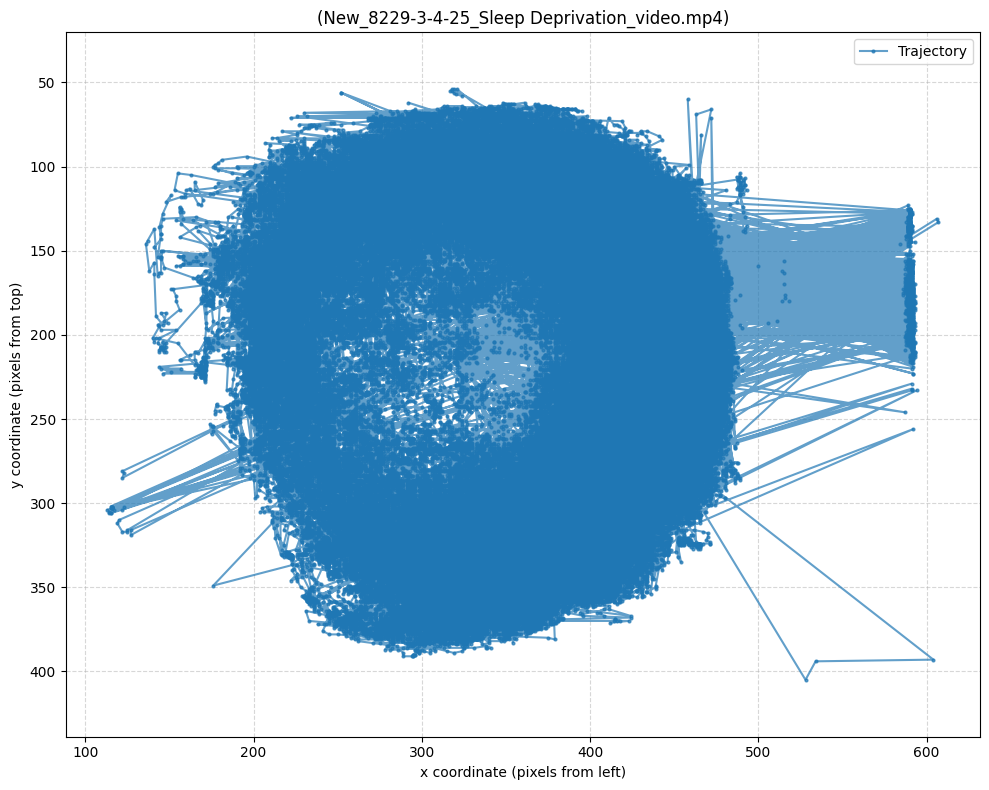

In [24]:
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"CSV file not found: {csv_path}. Please run the detection script first.")

df = pd.read_csv(csv_path)

if df.empty:
    print(f"The CSV file '{csv_path}' is empty. Cannot generate plots.")
    exit()

# --- Plot 1: Trajectory (Your existing code) ---
plt.figure(figsize=(10, 8)) # You can adjust figure size
# plot the trajectory
plt.plot(df["x_center"], df["y_center"],
         "-", marker=".", markersize=4, alpha=0.7, label="Trajectory")
# mark the origin (top-left of the frame)
# plt.scatter([0], [0],
#             color="red", marker="x", s=80, label="Origin (0,0 - Top-Left)")

# Mark the frame boundaries if desired
# plt.plot([0, frame_w, frame_w, 0, 0], [0, 0, frame_h, frame_h, 0], 'k--', alpha=0.5, label="Frame Boundary")


plt.gca().invert_yaxis()            # y increases downward
plt.xlabel("x coordinate (pixels from left)")
plt.ylabel("y coordinate (pixels from top)")
plt.legend(loc="best") # Changed to "best" or "upper right"
plt.xlim(0, frame_w)
plt.ylim(frame_h, 0) # Inverted y-axis means higher value is at the bottom of plot
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal') # Enforce aspect ratio based on data ranges
plt.title(f"({os.path.basename(input_video_path)})")
plt.tight_layout()
plt.show()

### HeatMap

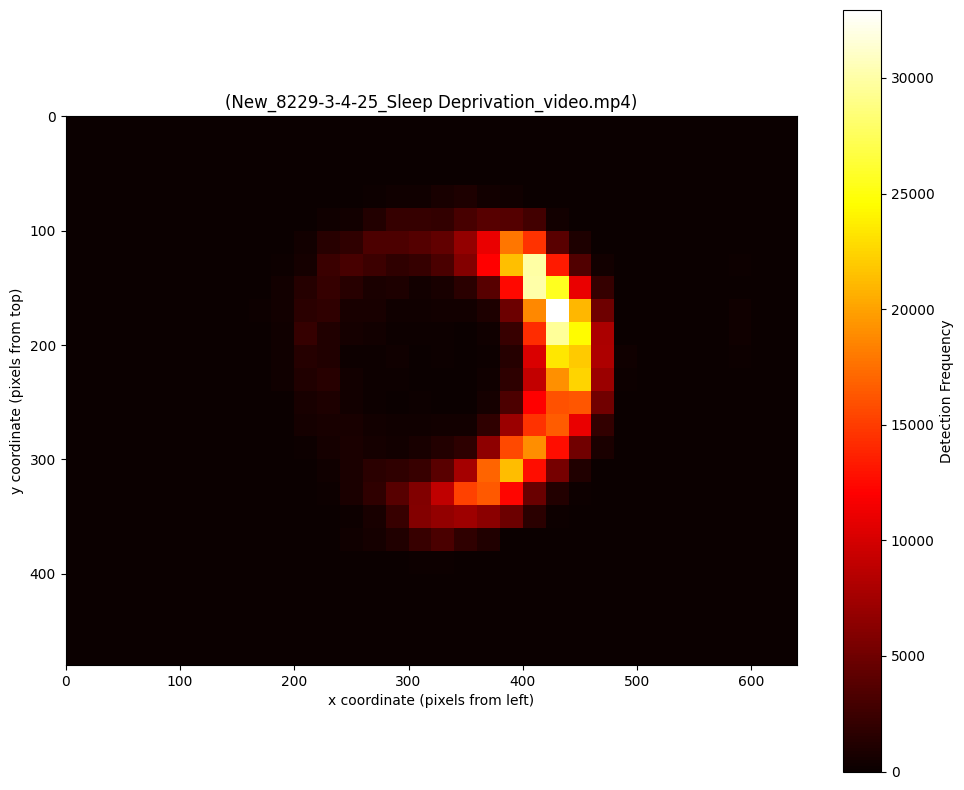

Plotting complete.


In [25]:
# --- Plot 2: Heatmap ---
plt.figure(figsize=(10, 8)) # New figure for the heatmap

# Number of bins for the 2D histogram. Adjust for desired granularity.
# More bins = finer detail but might be sparse if few data points.
# Fewer bins = coarser detail but better for visualizing general areas.
num_bins_x = frame_w // 20  # Example: 20 pixel wide bins
num_bins_y = frame_h // 20  # Example: 20 pixel tall bins
# Or fixed number of bins:
# num_bins_x = 50
# num_bins_y = 50


# Create the 2D histogram / heatmap
# counts: The 2D array of bin counts
# xedges, yedges: The bin edges
# image: The QuadMesh object returned by hist2d (we can use it or ignore it)
counts, xedges, yedges, image = plt.hist2d(
    df["x_center"],
    df["y_center"],
    bins=[num_bins_x, num_bins_y],  # Can be a single int for square bins or [binsx, binsy]
    range=[[0, frame_w], [0, frame_h]], # Ensure heatmap covers the whole frame
    cmap='hot'  # Colormap (e.g., 'hot', 'viridis', 'plasma', 'inferno', 'magma')
    # cmin=1 # Optional: set minimum count to display a color (useful to hide empty bins)
)

plt.colorbar(label='Detection Frequency')
plt.gca().invert_yaxis() # Match image coordinates (y increases downwards)
plt.xlabel("x coordinate (pixels from left)")
plt.ylabel("y coordinate (pixels from top)")
plt.xlim(0, frame_w)
plt.ylim(frame_h, 0) # Inverted y-axis
# plt.axis('equal') # Optional: if you want the aspect ratio of bins to be square based on data
plt.gca().set_aspect('equal', adjustable='box') # Better for ensuring visual squareness
plt.title(f"({os.path.basename(input_video_path)})")
plt.tight_layout()
plt.show()

print("Plotting complete.")

# Complete Speed Plots

C:\Users\mzarrar\AppData\Local\Temp\ipykernel_3408\1396364039.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_avg_speed_mean   = df["speed_px_per_sec"].resample("1H").mean().fillna(0)
C:\Users\mzarrar\AppData\Local\Temp\ipykernel_3408\1396364039.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_avg_speed_median = df["speed_px_per_sec"].resample("1H").median().fillna(0)


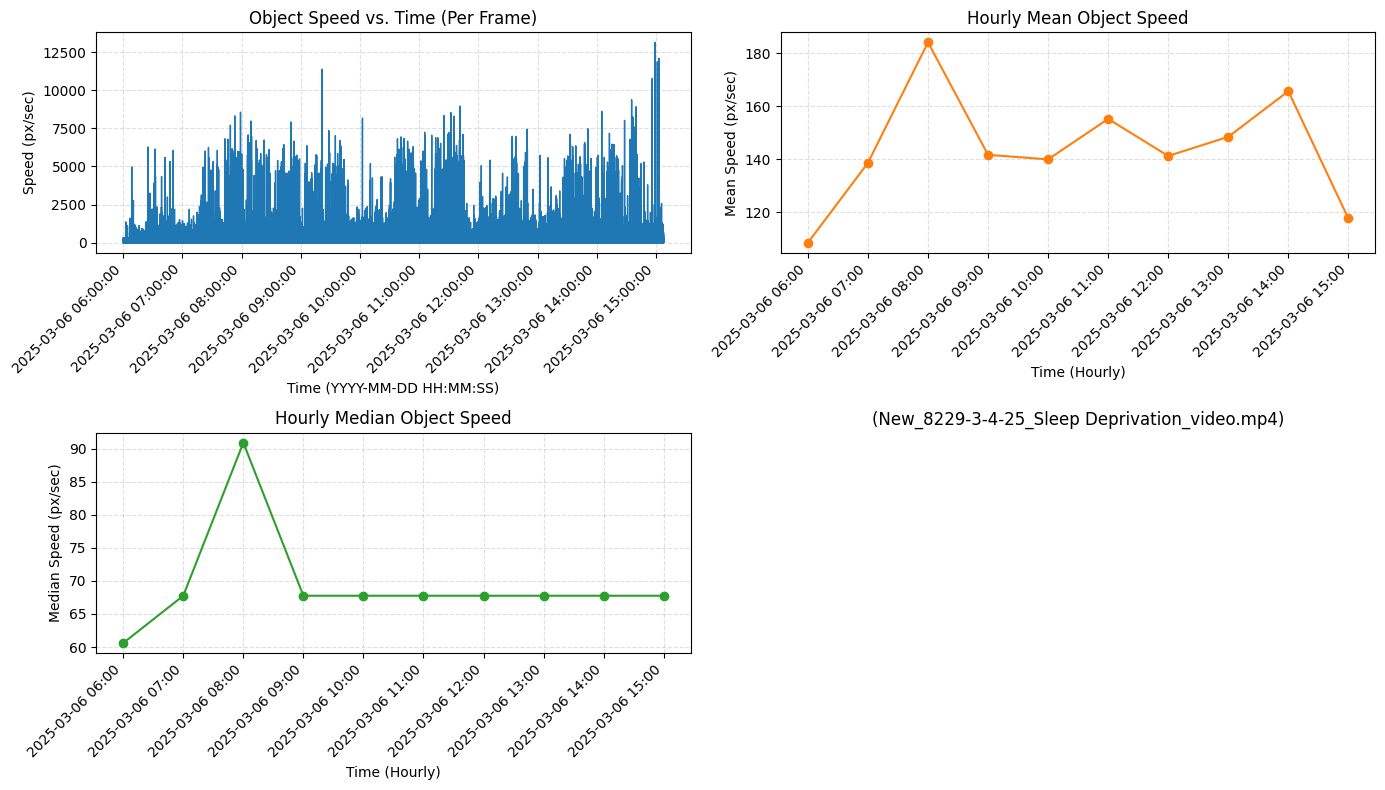

In [23]:
df = pd.read_csv(csv_path)
df["timestamp"] = pd.to_datetime(df["timestamp"], format="%Y-%m-%d %H:%M:%S")
df.set_index("timestamp", inplace=True)

# 2) Extract per‐frame speed series (fill missing as 0)
per_second_speed = df["speed_px_per_sec"].fillna(0)

# 3) Compute hourly average speed (mean and median)
hourly_avg_speed_mean   = df["speed_px_per_sec"].resample("1H").mean().fillna(0)
hourly_avg_speed_median = df["speed_px_per_sec"].resample("1H").median().fillna(0)

# 4) Create a 2×2 grid of subplots
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(14, 8), sharey=False)

# ——————————————————————————————————————————————
# Top‐left: per‐second speed vs. timestamp (ax = axs[0,0])
# ——————————————————————————————————————————————
ax1 = axs[0, 0]
ax1.plot(per_second_speed.index, per_second_speed.values, linewidth=1, color="tab:blue")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M:%S"))
ax1.set_xlabel("Time (YYYY-MM-DD HH:MM:SS)")
ax1.set_ylabel("Speed (px/sec)")
ax1.set_title("Object Speed vs. Time (Per Frame)")
ax1.grid(True, linestyle="--", alpha=0.4)
for label in ax1.get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

# ——————————————————————————————————————————————
# Top‐right: hourly mean speed vs. hour (ax = axs[0,1])
# ——————————————————————————————————————————————
ax2 = axs[0, 1]
ax2.plot(hourly_avg_speed_mean.index, hourly_avg_speed_mean.values,
         marker="o", linestyle="-", color="tab:orange")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
ax2.set_xlabel("Time (Hourly)")
ax2.set_ylabel("Mean Speed (px/sec)")
ax2.set_title("Hourly Mean Object Speed")
ax2.grid(True, linestyle="--", alpha=0.4)
for label in ax2.get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

# ——————————————————————————————————————————————
# Bottom‐left: hourly median speed vs. hour (ax = axs[1,0])
# ——————————————————————————————————————————————
ax3 = axs[1, 0]
ax3.plot(hourly_avg_speed_median.index, hourly_avg_speed_median.values,
         marker="o", linestyle="-", color="tab:green")
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
ax3.set_xlabel("Time (Hourly)")
ax3.set_ylabel("Median Speed (px/sec)")
ax3.set_title("Hourly Median Object Speed")
ax3.grid(True, linestyle="--", alpha=0.4)
for label in ax3.get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

# ——————————————————————————————————————————————
# Bottom‐right: empty (ax = axs[1,1]) – placeholder or remove if not needed
# ——————————————————————————————————————————————
ax4 = axs[1, 1]
ax4.axis("off")  # turn off this subplot entirely
# ——————————————————————————————————————————————
# 5) TIGHT LAYOUT & SHOW
# ——————————————————————————————————————————————
plt.title(f"({os.path.basename(input_video_path)})")
plt.tight_layout()
plt.show()


# Comparing 2 files

### Total Distance traveled

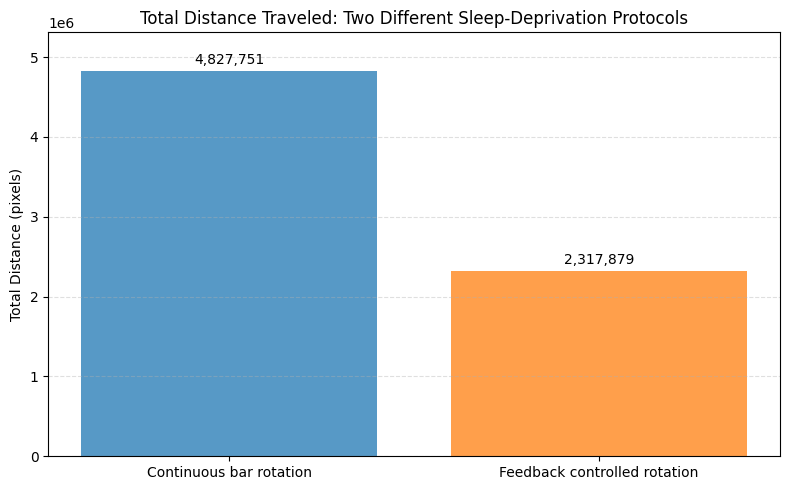

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# =========================================
# 1) CONFIGURATION: define your two inputs
# =========================================

pairs = [
    # (video_path, csv_path)
    (
        "Video/New_8229-3-4-25_Sleep Deprivation_video.mp4",
        "Trajectory & Speed Data  New 8229 - Rat 2 - 3-4-25 START_2025-03-04_Sleep Deprivation.csv"
    ),
    (
        "Video/Feedback Deprivation - Full File - Rat 2- 4-25-25 Start_video.mp4",
        "Feedback Trajectory and Speed Data - Full File - Rat 2- 4-25-25 Start_video.csv"
    )
]

# For labeling (you can replace with any short strings you like)
labels = [
    "Continuous bar rotation",
    "Feedback controlled rotation"
]

# Ensure labels and pairs have the same length
assert len(pairs) == len(labels), "Number of labels must match number of (video, csv) pairs"

# ========================================================
# 2) FUNCTION TO COMPUTE TOTAL DISTANCE FROM A TRAJECTORY CSV
# ========================================================
def total_distance_from_csv(csv_path):
    """
    Reads a CSV that must have at least 'frame', 'x_center', 'y_center'.
    Computes the total Euclidean distance traveled by summing
    sqrt((x[i] - x[i-1])^2 + (y[i] - y[i-1])^2) over consecutive rows.
    """
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV file not found: {csv_path}")
    
    df = pd.read_csv(csv_path)
    if df.empty:
        return 0.0
    
    # Ensure the DataFrame is sorted by 'frame' (in case it isn't already)
    if "frame" in df.columns:
        df = df.sort_values("frame").reset_index(drop=True)
    
    # Convert x_center/y_center to numeric (in case they were strings)
    # (If your columns are already numeric, this is harmless.)
    df["x_center"] = pd.to_numeric(df["x_center"], errors="coerce")
    df["y_center"] = pd.to_numeric(df["y_center"], errors="coerce")
    
    # Compute differences between consecutive points
    dx = df["x_center"].diff().fillna(0)
    dy = df["y_center"].diff().fillna(0)
    
    # Euclidean distance per step
    step_dist = np.sqrt(dx**2 + dy**2)
    
    # Sum all step distances
    total_dist = step_dist.sum()
    return total_dist

# ========================================================
# 3) LOOP OVER EACH CSV, COMPUTE TOTAL DISTANCE
# ========================================================
distances = []
for (video_path, csv_path) in pairs:
    dist = total_distance_from_csv(csv_path)
    distances.append(dist)

# ========================================================
# 4) PLOT SIDE‐BY‐SIDE BAR CHART OF TOTAL DISTANCES
# ========================================================
x_pos = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(x_pos, distances, color=["tab:blue", "tab:orange"], alpha=0.75)

# Annotate each bar with its numeric value
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(distances)*0.01,  # place text slightly above the bar
        f"{height:,.0f}",             # no decimals—just an integer
        ha="center", va="bottom", fontsize=10
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel("Total Distance (pixels)")
ax.set_title("Total Distance Traveled: Two Different Sleep‐Deprivation Protocols")
ax.grid(axis="y", linestyle="--", alpha=0.4)


# 1) Increase top margin by extending y-limit by 10%
ymax = max(distances) * 1.10
ax.set_ylim(0, ymax)

plt.tight_layout()
plt.show()

### Average velocity per 30 minute period over the 24 hr deprivation period

C:\Users\mzarrar\AppData\Local\Temp\ipykernel_3408\1512689859.py:43: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  mean_30min = df["speed_px_per_sec"].resample("30T").mean().fillna(0)
C:\Users\mzarrar\AppData\Local\Temp\ipykernel_3408\1512689859.py:43: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  mean_30min = df["speed_px_per_sec"].resample("30T").mean().fillna(0)


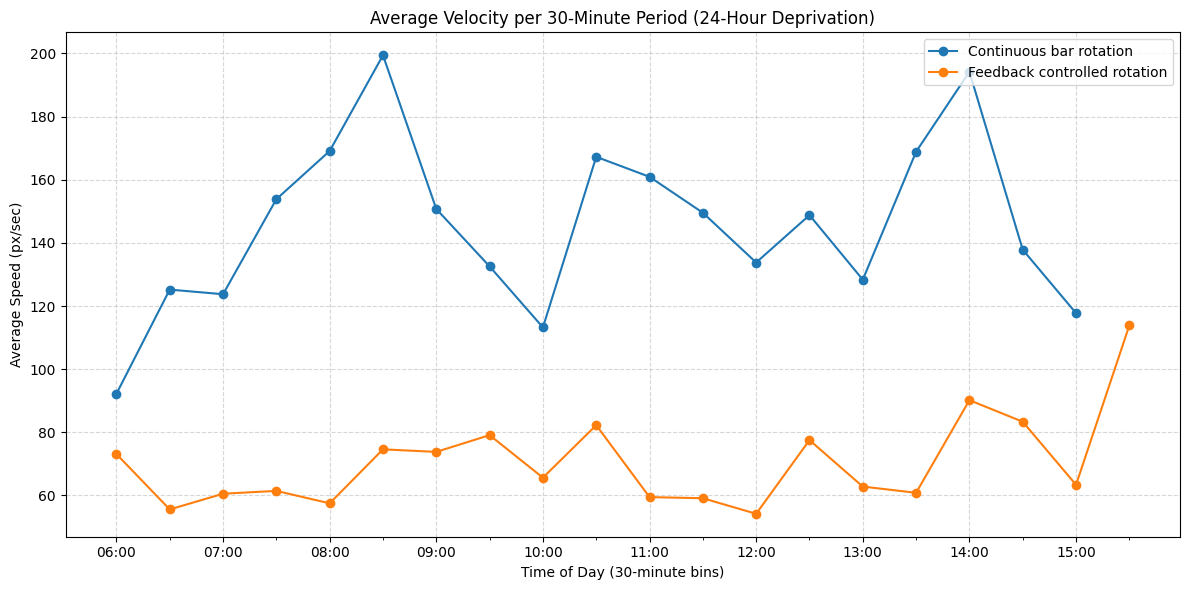

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# ================================
# 1) CONFIGURATION: file paths
# ================================
file_info = [
    {
        "label": "Continuous bar rotation", 
        "video": "Video/New_8229-3-4-25_Sleep Deprivation_video.mp4",
        "csv":   "Trajectory & Speed Data  New 8229 - Rat 2 - 3-4-25 START_2025-03-04_Sleep Deprivation.csv"
    },
    {
        "label": "Feedback controlled rotation", 
        "video": "Video/Feedback Deprivation - Full File - Rat 2- 4-25-25 Start_video.mp4",
        "csv":   "Feedback Trajectory and Speed Data - Full File - Rat 2- 4-25-25 Start_video.csv"
    }
]

# Verify that each CSV exists
for info in file_info:
    if not os.path.exists(info["csv"]):
        raise FileNotFoundError(f"Could not find CSV: {info['csv']}")

# ============================================
# 2) LOAD, PARSE TIMESTAMP, AND RESAMPLE DATA
# ============================================
# We'll compute the 30-minute average speed for each of the two CSVs.
resampled_list = []
for info in file_info:
    # 2a) Read CSV and parse timestamp
    df = pd.read_csv(info["csv"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], format="%Y-%m-%d %H:%M:%S")
    df.set_index("timestamp", inplace=True)

    # 2b) Ensure the 'speed_px_per_sec' column is numeric
    df["speed_px_per_sec"] = pd.to_numeric(df["speed_px_per_sec"], errors="coerce").fillna(0)

    # 2c) Resample into 30-minute bins, taking the mean speed in each bin
    #     The result is a Series indexed by each 30-minute boundary.
    mean_30min = df["speed_px_per_sec"].resample("30T").mean().fillna(0)

    # 2d) Store into a list (along with its label)
    resampled_list.append((info["label"], mean_30min))

# ============================================
# 3) PLOT BOTH SERIES ON A SINGLE AXIS
# ============================================
fig, ax = plt.subplots(figsize=(12, 6))

for label, series in resampled_list:
    ax.plot(
        series.index, 
        series.values, 
        marker="o", 
        linestyle="-", 
        linewidth=1.5, 
        label=label
    )

# 3a) Format the x-axis to show hours and minutes
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))                # tick every hour
ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[0,30]))        # minor ticks at :00 and :30
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))               # format as HH:MM

# 3b) Rotate x-tick labels for readability
plt.xticks(rotation=0)

# 3c) Labels, title, grid, legend
ax.set_xlabel("Time of Day (30-minute bins)")
ax.set_ylabel("Average Speed (px/sec)")
ax.set_title("Average Velocity per 30-Minute Period (24-Hour Deprivation)")
ax.grid(which="major", linestyle="--", alpha=0.5)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

### Total time spent immobile over 24 hr deprivation period.

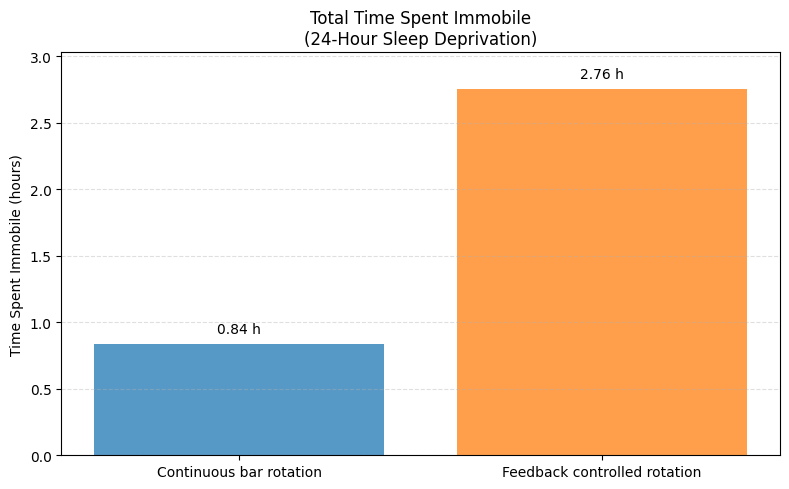

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# =======================================
# 1) CONFIGURE: video + CSV for each run
# =======================================
runs = [
    {
        "label": "Continuous bar rotation", 
        "video": "Video/New_8229-3-4-25_Sleep Deprivation_video.mp4",
        "csv":   "Trajectory & Speed Data  New 8229 - Rat 2 - 3-4-25 START_2025-03-04_Sleep Deprivation.csv"
    },
    {
        "label": "Feedback controlled rotation", 
        "video": "Video/Feedback Deprivation - Full File - Rat 2- 4-25-25 Start_video.mp4",
        "csv":   "Feedback Trajectory and Speed Data - Full File - Rat 2- 4-25-25 Start_video.csv"
    }
]

# Verify that all files exist
for run in runs:
    if not os.path.exists(run["video"]):
        raise FileNotFoundError(f"Video not found: {run['video']}")
    if not os.path.exists(run["csv"]):
        raise FileNotFoundError(f"CSV not found:   {run['csv']}")

# ======================================================
# 2) FUNCTION TO COMPUTE TOTAL IMMOBILE TIME (HOURS)
# ======================================================
def immobile_time_hours(video_path, csv_path):
    """
    - Reads the CSV which must contain a 'speed_px_per_sec' column.
    - Finds how many frames have speed == 0.
    - Reads the video to get its FPS.
    - Returns (immobile_frames / fps) in HOURS.
    """
    # 2a) Load CSV
    df = pd.read_csv(csv_path)
    if "speed_px_per_sec" not in df.columns:
        raise ValueError(f"'speed_px_per_sec' column missing in {csv_path}")
    if df.empty:
        return 0.0

    # 2b) Count frames where speed == 0 (immobile)
    #     (We treat exactly zero as "fully immobile".)
    immobile_frames = (df["speed_px_per_sec"] == 0).sum()

    # 2c) Read the video to get FPS
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {video_path}")
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()

    # 2d) Compute immobile time in seconds, then convert to hours
    immobile_seconds = immobile_frames / fps
    immobile_hours = immobile_seconds / 3600.0
    return immobile_hours

# =========================================
# 3) COMPUTE IMMOBILE HOURS FOR BOTH RUNS
# =========================================
immobile_hours_list = []
for run in runs:
    hrs = immobile_time_hours(run["video"], run["csv"])
    immobile_hours_list.append(hrs)

# =========================================
# 4) PLOT SIDE-BY-SIDE BAR CHART
# =========================================
labels = [run["label"] for run in runs]
values = immobile_hours_list

x_pos = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(x_pos, values, color=["tab:blue", "tab:orange"], alpha=0.75)

# Annotate each bar with its height (formatted to two decimal places)
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + max(values) * 0.02,        # tiny offset above the bar
        f"{h:.2f} h",                 # show in hours
        ha="center", va="bottom",
        fontsize=10
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel("Time Spent Immobile (hours)")
ax.set_title("Total Time Spent Immobile\n(24-Hour Sleep Deprivation)")
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Add ~10% headroom above the tallest bar
ymax = max(values) * 1.10
ax.set_ylim(0, ymax)

plt.tight_layout()
plt.show()


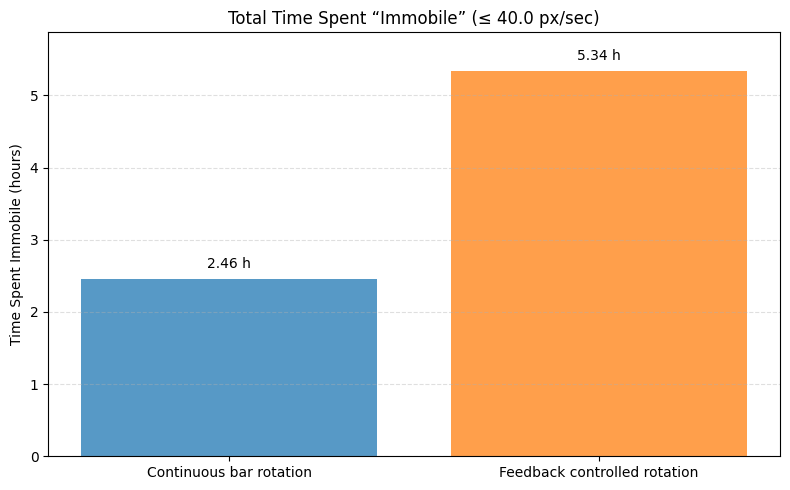

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# =======================================
# 1) CONFIGURE: video + CSV for each run
# =======================================
runs = [
    {
        "label": "Continuous bar rotation", 
        "video": "Video/New_8229-3-4-25_Sleep Deprivation_video.mp4",
        "csv":   "Trajectory & Speed Data  New 8229 - Rat 2 - 3-4-25 START_2025-03-04_Sleep Deprivation.csv"
    },
    {
        "label": "Feedback controlled rotation", 
        "video": "Video/Feedback Deprivation - Full File - Rat 2- 4-25-25 Start_video.mp4",
        "csv":   "Feedback Trajectory and Speed Data - Full File - Rat 2- 4-25-25 Start_video.csv"
    }
]

# Verify that all files exist
for run in runs:
    if not os.path.exists(run["video"]):
        raise FileNotFoundError(f"Video not found: {run['video']}")
    if not os.path.exists(run["csv"]):
        raise FileNotFoundError(f"CSV not found:   {run['csv']}")

# ======================================================
# 2) FUNCTION TO COMPUTE TOTAL IMMOBILE TIME (HOURS)
#    (counts speeds ≤ 40 px/sec as “immobile”)
# ======================================================
def immobile_time_hours(video_path, csv_path, threshold=40.0):
    """
    - Reads the CSV which must contain a 'speed_px_per_sec' column.
    - Counts how many frames have 0 ≤ speed_px_per_sec ≤ threshold.
    - Reads the video to get its FPS.
    - Returns (immobile_frames / fps) in HOURS.
    """
    # 2a) Load CSV
    df = pd.read_csv(csv_path)
    if "speed_px_per_sec" not in df.columns:
        raise ValueError(f"'speed_px_per_sec' column missing in {csv_path}")
    if df.empty:
        return 0.0

    # 2b) Count frames where speed is in [0, threshold]
    immobile_frames = ((df["speed_px_per_sec"] >= 0) & 
                       (df["speed_px_per_sec"] <= threshold)).sum()

    # 2c) Read the video to get FPS
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {video_path}")
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()

    # 2d) Compute immobile time in seconds, then convert to hours
    immobile_seconds = immobile_frames / fps
    immobile_hours = immobile_seconds / 3600.0
    return immobile_hours

# =========================================
# 3) COMPUTE IMMOBILE HOURS FOR BOTH RUNS
# =========================================
threshold_px_per_sec = 40.0
immobile_hours_list = []
for run in runs:
    hrs = immobile_time_hours(run["video"], run["csv"], threshold=threshold_px_per_sec)
    immobile_hours_list.append(hrs)

# =========================================
# 4) PLOT SIDE-BY-SIDE BAR CHART
# =========================================
labels = [run["label"] for run in runs]
values = immobile_hours_list

x_pos = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(x_pos, values, color=["tab:blue", "tab:orange"], alpha=0.75)

# Annotate each bar with its height (formatted to two decimal places)
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + max(values) * 0.02,    # tiny offset above the bar
        f"{h:.2f} h",              # show in hours
        ha="center", va="bottom",
        fontsize=10
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel("Time Spent Immobile (hours)")
ax.set_title(f"Total Time Spent “Immobile” (≤ {threshold_px_per_sec} px/sec)")
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Add ~10% headroom above the tallest bar
ymax = max(values) * 1.10
ax.set_ylim(0, ymax)

plt.tight_layout()
plt.show()


### Total time spent above some minimal threshold of velocity (time spent moving) over the 24 hour period.


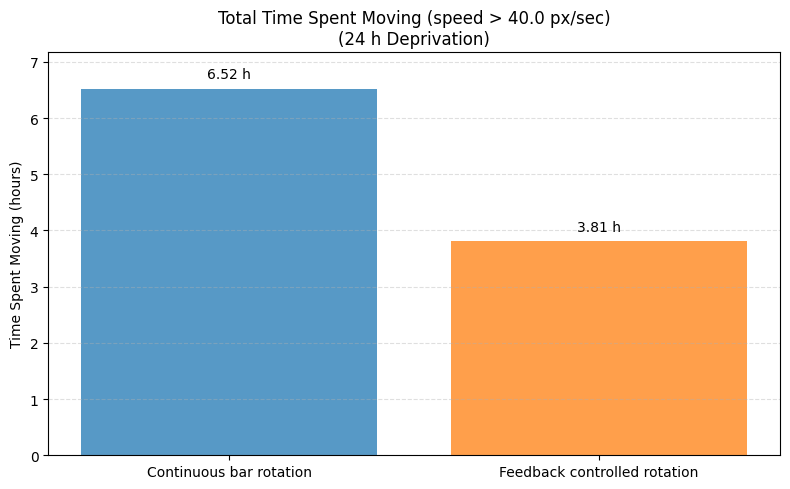

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# =======================================
# 1) CONFIGURE: video + CSV for each run
# =======================================
runs = [
    {
        "label": "Continuous bar rotation", 
        "video": "Video/New_8229-3-4-25_Sleep Deprivation_video.mp4",
        "csv":   "Trajectory & Speed Data  New 8229 - Rat 2 - 3-4-25 START_2025-03-04_Sleep Deprivation.csv"
    },
    {
        "label": "Feedback controlled rotation", 
        "video": "Video/Feedback Deprivation - Full File - Rat 2- 4-25-25 Start_video.mp4",
        "csv":   "Feedback Trajectory and Speed Data - Full File - Rat 2- 4-25-25 Start_video.csv"
    }
]

# Verify that all files exist
for run in runs:
    if not os.path.exists(run["video"]):
        raise FileNotFoundError(f"Video not found: {run['video']}")
    if not os.path.exists(run["csv"]):
        raise FileNotFoundError(f"CSV not found:   {run['csv']}")

# ======================================================
# 2) FUNCTION TO COMPUTE TOTAL MOVING TIME (HOURS)
#    (counts speeds > threshold as “moving”)
# ======================================================
def moving_time_hours(video_path, csv_path, threshold=40.0):
    """
    - Reads the CSV which must contain a 'speed_px_per_sec' column.
    - Counts how many frames have speed > threshold.
    - Reads the video to get its FPS.
    - Returns (moving_frames / fps) in HOURS.
    """
    # 2a) Load CSV
    df = pd.read_csv(csv_path)
    if "speed_px_per_sec" not in df.columns:
        raise ValueError(f"'speed_px_per_sec' column missing in {csv_path}")
    if df.empty:
        return 0.0

    # 2b) Count frames where speed > threshold (moving)
    moving_frames = (df["speed_px_per_sec"] > threshold).sum()

    # 2c) Read the video to get FPS
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {video_path}")
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.release()

    # 2d) Compute moving time in seconds, then convert to hours
    moving_seconds = moving_frames / fps
    moving_hours = moving_seconds / 3600.0
    return moving_hours

# =========================================
# 3) COMPUTE MOVING HOURS FOR BOTH RUNS
# =========================================
threshold_px_per_sec = 40.0
moving_hours_list = []
for run in runs:
    hrs = moving_time_hours(run["video"], run["csv"], threshold=threshold_px_per_sec)
    moving_hours_list.append(hrs)

# =========================================
# 4) PLOT SIDE-BY-SIDE BAR CHART
# =========================================
labels = [run["label"] for run in runs]
values = moving_hours_list

x_pos = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(x_pos, values, color=["tab:blue", "tab:orange"], alpha=0.75)

# Annotate each bar with its height (formatted to two decimal places)
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + max(values) * 0.02,        # tiny offset above the bar
        f"{h:.2f} h",                  # show in hours
        ha="center", va="bottom",
        fontsize=10
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel("Time Spent Moving (hours)")
ax.set_title(f"Total Time Spent Moving (speed > {threshold_px_per_sec} px/sec)\n(24 h Deprivation)")
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Add ~10% headroom above the tallest bar
ymax = max(values) * 1.10
ax.set_ylim(0, ymax)

plt.tight_layout()
plt.show()
